# Análisis exploratorio de datos

Este cuaderno caracteriza los datos del Healthy Brain Network publicados en la competencia de Kaggle del Child Mind Institute. Corresponde al objetivo específico 1 del proyecto: describir la disponibilidad, la calidad y la distribución del índice de severidad del deterioro (SII), de los indicadores físicos y demográficos y de las variables complementarias, y definir con base en ello el tratamiento de los datos faltantes y del desbalance entre niveles de severidad.

El análisis sigue el orden de las decisiones que alimenta: primero la integridad y la estructura de los datos, luego la variable objetivo y la población de análisis, después la calidad de los predictores (faltantes, valores inválidos, distribuciones y redundancia) y, por último, la relación descriptiva de cada grupo de variables con el SII.

Dos criterios se aplican en todo el cuaderno. Como los datos corresponden a menores de edad, todas las salidas son agregadas: conteos, porcentajes, estadísticos y gráficas. Además, la relación entre los predictores y el SII se analiza solo de forma descriptiva; la selección de variables que dependa de la variable objetivo ocurre dentro de la validación cruzada, en el cuaderno de modelado.


In [204]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from piu_severity.config import FIGURES_DIR, RANDOM_SEED
from piu_severity.data.load import load_data_dictionary, load_test, load_train
from piu_severity.features.groups import (
    column_group,
    feature_set_columns,
    is_excluded,
    is_instrument_season,
)
from piu_severity.visualization.figures import save_figure

In [205]:
pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
rng = np.random.default_rng(RANDOM_SEED)

In [206]:
train = load_train()
test = load_test()
data_dictionary = load_data_dictionary()

## 1. Carga y verificación de integridad

Antes de caracterizar las variables se verifica que los archivos cargados correspondan a lo esperado. La verificación cubre cuatro aspectos: las dimensiones de los conjuntos de entrenamiento y prueba y del diccionario de datos; la unicidad del identificador de participante; la relación entre las columnas y los registros de ambos conjuntos; y la correspondencia entre las columnas de entrenamiento y los campos documentados en el diccionario.

Esta verificación sustenta dos decisiones: qué columnas quedan excluidas como predictores por definir la variable objetivo, y qué papel cumple el archivo de prueba en el análisis.


In [207]:
dimensiones = pd.DataFrame(
    {
        "filas": [train.shape[0], test.shape[0], data_dictionary.shape[0]],
        "columnas": [train.shape[1], test.shape[1], data_dictionary.shape[1]],
    },
    index=["train", "test", "diccionario"],
)
dimensiones

,filas,columnas
train,3960,82
test,20,59
diccionario,81,6


In [208]:
data_dictionary.head()

,Instrument,Field,Description,Type,Values,Value Labels
0,Identifier,id,Participant's ID,str,NaN,NaN
1,Demographics,Basic_Demos-Enroll_Season,Season of enrollment,str,"Spring, Summer, Fall, Winter",NaN
2,Demographics,Basic_Demos-Age,Age of participant,float,NaN,NaN
3,Demographics,Basic_Demos-Sex,Sex of participant,categorical int,"0,1","0=Male, 1=Female"
4,Children's Global Assessment Scale,CGAS-Season,Season of participation,str,"Spring, Summer, Fall, Winter",NaN


In [209]:
pd.Series(
    {
        "id duplicados en train": train["id"].duplicated().sum(),
        "id duplicados en test": test["id"].duplicated().sum(),
        "id faltantes en train": train["id"].isna().sum(),
        "id faltantes en test": test["id"].isna().sum(),
    },
    name="conteo",
)

id duplicados en train    0
id duplicados en test     0
id faltantes en train     0
id faltantes en test      0
Name: conteo, dtype: int64

In [210]:
ids_compartidos = test["id"].isin(train["id"])
columnas_comunes = test.columns.drop("id")
filas_test = test.loc[ids_compartidos].set_index("id")[columnas_comunes]
filas_train = train.set_index("id").loc[filas_test.index, columnas_comunes]
coinciden = filas_train.eq(filas_test) | (filas_train.isna() & filas_test.isna())

pd.Series(
    {
        "registros de test": len(test),
        "registros de test con id en train": ids_compartidos.sum(),
        "registros de test idénticos a su fila de train": coinciden.all(
            axis="columns"
        ).sum(),
        "registros compartidos con SII en train": (
            train.set_index("id").loc[filas_test.index, "sii"].notna().sum()
        ),
    },
    name="conteo",
)

registros de test                                 20
registros de test con id en train                 20
registros de test idénticos a su fila de train    20
registros compartidos con SII en train            11
Name: conteo, dtype: int64

In [211]:
columnas_train = set(train.columns)
columnas_test = set(test.columns)
solo_test = columnas_test - columnas_train
solo_train = columnas_train - columnas_test

assert not solo_test
columnas_objetivo = {
    columna for columna in train.columns if columna.startswith("PCIAT-")
} | {"sii"}
assert solo_train == columnas_objetivo

orden_train = train.columns[train.columns.isin(columnas_test)]
orden_test = test.columns[test.columns.isin(columnas_train)]
print(
    "El orden de las columnas comunes es idéntico:",
    orden_train.equals(orden_test),
)

(
    pd.Series(sorted(solo_train))
    .str.split("-", n=1)
    .str[0]
    .value_counts()
    .rename("columnas exclusivas de train")
    .rename_axis("prefijo")
)

El orden de las columnas comunes es idéntico: True


prefijo
PCIAT    22
sii       1
Name: columnas exclusivas de train, dtype: int64

In [212]:
campos = set(data_dictionary["Field"])
sin_documentar = sorted(set(train.columns) - campos)
ausentes = sorted(campos - set(train.columns))

display(
    pd.Series(
        {
            "campos del diccionario": len(data_dictionary),
            "campos duplicados en el diccionario": data_dictionary["Field"]
            .duplicated()
            .sum(),
            "columnas de train sin documentar": len(sin_documentar),
            "campos documentados ausentes en train": len(ausentes),
        },
        name="conteo",
    )
)
print(sin_documentar)
print(ausentes)
data_dictionary.groupby("Instrument", sort=False)["Field"].count().rename("campos")

campos del diccionario                   81
campos duplicados en el diccionario       0
columnas de train sin documentar          1
campos documentados ausentes en train     0
Name: conteo, dtype: int64

['sii']
[]


Instrument
Identifier                                        1
Demographics                                      3
Children's Global Assessment Scale                2
Physical Measures                                 8
FitnessGram Vitals and Treadmill                  4
FitnessGram Child                                15
Bio-electric Impedance Analysis                  17
Physical Activity Questionnaire (Adolescents)     2
Physical Activity Questionnaire (Children)        2
Parent-Child Internet Addiction Test             22
Sleep Disturbance Scale                           3
Internet Use                                      2
Name: campos, dtype: int64

### Conclusión

La verificación confirma la estructura esperada de los datos y sustenta dos decisiones para el resto del análisis.

**Conjunto de entrenamiento.** Contiene 3.960 registros y 82 columnas, sin identificadores faltantes ni duplicados.

**Columnas excluidas como predictores.** Las 23 columnas exclusivas del conjunto de entrenamiento corresponden a:

- los 22 campos del PCIAT: los 20 ítems, el puntaje total y la temporada de aplicación;
- el SII.

Estas columnas definen la variable objetivo, por lo que se excluyen como predictores junto con el identificador del participante. Las 58 columnas restantes, sin contar el identificador, son comunes a ambos conjuntos, conservan el mismo orden y constituyen los predictores candidatos.

**Archivo de prueba.** Sus 20 registros coinciden en todas las columnas con registros del conjunto de entrenamiento, y 11 de ellos tienen el SII registrado. El archivo es la muestra de ejemplo que acompaña a la competencia, cuyo conjunto de prueba real permanece oculto. Como no aporta participantes nuevos, no se utiliza en el resto del análisis ni en el modelado.

**Diccionario de datos.** Documenta 81 campos sin duplicados, agrupados en 11 instrumentos más el identificador, y cubre todas las columnas del conjunto de entrenamiento excepto el SII. La relación entre el SII y el puntaje total del PCIAT se examina en la sección 3.

## 2. Estructura y tipología de las variables

Una vez definidas las columnas excluidas, cada columna restante se asigna a un grupo y a un tipo de variable. Los grupos siguen la formulación del proyecto:

- **Demográfico:** edad, sexo y temporada de inscripción.
- **Físico:** medidas antropométricas y signos vitales, FitnessGram, resistencia cardiorrespiratoria, bioimpedancia y actividad física autorreportada.
- **Complementario:** alteraciones del sueño, funcionamiento global y horas diarias de uso de computador e internet.

Las columnas de temporada de participación de cada instrumento se tratan como una categoría aparte, porque registran cuándo se aplicó la medición y no una característica del participante. Su utilidad se evalúa junto con el patrón de valores faltantes.

El tipo de cada variable se toma del diccionario y se contrasta con los datos. Se verifica que los valores observados en las variables categóricas pertenezcan a los valores documentados y que las variables declaradas como enteras contengan solo valores enteros. A partir de esta clasificación se definen los tres conjuntos de variables del proyecto y la codificación que requiere cada tipo.

In [213]:
GRUPOS_ES = {
    "demographic": "demográfico",
    "physical": "físico",
    "complementary": "complementario",
    "season": "temporada de instrumento",
}

diccionario = data_dictionary.set_index("Field")
columnas_analisis = [c for c in train.columns if not is_excluded(c)]


def tipo_analitico(tipo: str, valores: object) -> str:
    """Clasifica una variable según su tipo y valores documentados."""
    if tipo == "str":
        return "nominal"
    if tipo == "categorical int":
        return "binaria" if len(str(valores).split(",")) == 2 else "ordinal"
    return "numérica"


estructura = pd.DataFrame(
    {
        "instrumento": diccionario.loc[columnas_analisis, "Instrument"].to_numpy(),
        "grupo": [GRUPOS_ES[column_group(c)] for c in columnas_analisis],
        "tipo_diccionario": diccionario.loc[columnas_analisis, "Type"].to_numpy(),
        "tipo_analitico": [
            tipo_analitico(diccionario.at[c, "Type"], diccionario.at[c, "Values"])
            for c in columnas_analisis
        ],
        "dtype": train[columnas_analisis].dtypes.astype(str).to_numpy(),
    },
    index=pd.Index(columnas_analisis, name="columna"),
)

pd.crosstab(
    estructura["grupo"],
    estructura["tipo_analitico"],
    margins=True,
    margins_name="total",
)

tipo_analitico,binaria,nominal,numérica,ordinal,total
grupo,,,,,
complementario,0,0,3,1,4
demográfico,1,1,1,0,3
físico,5,0,33,4,42
temporada de instrumento,0,9,0,0,9
total,6,10,37,5,58


In [214]:
pd.crosstab(
    pd.Categorical(
        estructura["instrumento"],
        categories=estructura["instrumento"].unique(),
        ordered=True,
    ),
    estructura["grupo"],
    rownames=["instrumento"],
    colnames=["grupo"],
    margins=True,
    margins_name="total",
)

grupo,complementario,demográfico,físico,temporada de instrumento,total
instrumento,,,,,
Demographics,0,3,0,0,3
Children's Global Assessment Scale,1,0,0,1,2
Physical Measures,0,0,7,1,8
FitnessGram Vitals and Treadmill,0,0,3,1,4
FitnessGram Child,0,0,14,1,15
Bio-electric Impedance Analysis,0,0,16,1,17
Physical Activity Questionnaire (Adolescents),0,0,1,1,2
Physical Activity Questionnaire (Children),0,0,1,1,2
Sleep Disturbance Scale,2,0,0,1,3


In [215]:
def valores_normalizados(serie: pd.Series) -> set[str]:
    """Devuelve los valores distintos como texto, sin el sufijo decimal .0."""
    return set(serie.dropna().astype(str).str.replace(r"\.0$", "", regex=True))


filas = []
for columna in columnas_analisis:
    valores = diccionario.at[columna, "Values"]
    if pd.isna(valores):
        continue
    documentados = {v.strip() for v in str(valores).split(",")}
    observados = valores_normalizados(train[columna])
    filas.append(
        {
            "columna": columna,
            "valores documentados": len(documentados),
            "valores observados": len(observados),
            "fuera de lo documentado": len(observados - documentados),
        }
    )

pd.DataFrame(filas).set_index("columna")

,valores documentados,valores observados,fuera de lo documentado
columna,,,
Basic_Demos-Enroll_Season,4,4,0
Basic_Demos-Sex,2,2,0
CGAS-Season,4,4,0
Physical-Season,4,4,0
Fitness_Endurance-Season,4,4,0
FGC-Season,4,4,0
FGC-FGC_CU_Zone,2,2,0
FGC-FGC_GSND_Zone,3,3,0
FGC-FGC_GSD_Zone,3,3,0


In [216]:
declaradas_enteras = [
    c for c in columnas_analisis if diccionario.at[c, "Type"] in ("int", "categorical int")
]
no_enteros = pd.Series(
    {c: int((train[c].dropna() % 1 != 0).sum()) for c in declaradas_enteras},
    name="registros con valores no enteros",
)

print(f"Columnas declaradas como enteras: {len(declaradas_enteras)}")
print(f"Columnas con valores no enteros: {(no_enteros > 0).sum()}")
no_enteros[no_enteros > 0]

Columnas declaradas como enteras: 24
Columnas con valores no enteros: 2


Physical-Waist_Circumference     14
FGC-FGC_TL                      189
Name: registros con valores no enteros, dtype: int64

In [217]:
train["Basic_Demos-Age"].agg(["min", "max"]).rename("edad")

min     5
max    22
Name: edad, dtype: int64

In [218]:
CONJUNTOS_ES = {
    "reference": "referencia",
    "main": "principal",
    "complementary": "complementario",
}

conjuntos = {
    nombre_es: feature_set_columns(train.columns, nombre)
    for nombre, nombre_es in CONJUNTOS_ES.items()
}

assert (
    set(conjuntos["referencia"])
    <= set(conjuntos["principal"])
    <= set(conjuntos["complementario"])
)
assert not any(
    is_excluded(c) or is_instrument_season(c)
    for columnas in conjuntos.values()
    for c in columnas
)

tabla_conjuntos = (
    pd.DataFrame(
        {
            nombre: estructura.loc[columnas, "grupo"].value_counts()
            for nombre, columnas in conjuntos.items()
        }
    )
    .reindex(["demográfico", "físico", "complementario"])
    .fillna(0)
    .astype(int)
)
tabla_conjuntos.loc["total"] = tabla_conjuntos.sum()
tabla_conjuntos

,referencia,principal,complementario
grupo,,,
demográfico,3,3,3
físico,0,42,42
complementario,0,0,4
total,3,45,49


### Conclusión

Las 58 columnas que quedan tras la exclusión se distribuyen en 3 demográficas, 42 físicas, 4 complementarias y 9 temporadas de instrumento. A partir de esta clasificación, los conjuntos de variables del proyecto quedan conformados así:

| Conjunto | Demográficas | Físicas | Complementarias | Total |
|---|---|---|---|---|
| Referencia | 3 | 0 | 0 | 3 |
| Principal | 3 | 42 | 0 | 45 |
| Complementario | 3 | 42 | 4 | 49 |

Los tres conjuntos están anidados y no incluyen columnas excluidas ni temporadas de instrumento. Estas últimas quedan fuera de manera provisional, porque su utilidad depende del patrón de valores faltantes que se analiza más adelante.

**Consistencia con el diccionario.** Los valores observados en las 21 columnas categóricas pertenecen a los valores documentados, y la edad de los participantes está entre 5 y 22 años, como se describe en la formulación del proyecto. De las 24 columnas declaradas como enteras, dos contienen valores no enteros: la circunferencia de cintura (14 registros) y el levantamiento de tronco de FitnessGram (189 registros). Ambas son medidas continuas de longitud, por lo que la discrepancia corresponde al tipo declarado en el diccionario y no impide su uso; se tratan como variables numéricas.

**Codificación por tipo de variable.**

- **Numéricas (37):** se conservan en su escala original. Para la regresión logística y las máquinas de soporte vectorial se estandarizan dentro del flujo de procesamiento, con parámetros calculados en cada partición de entrenamiento.
- **Binarias (6):** el sexo y cinco zonas de FitnessGram, ya codificadas como 0 y 1, se usan sin transformación.
- **Ordinales (5):** las dos zonas de fuerza de agarre, el nivel de actividad y la contextura de la bioimpedancia, y las horas diarias de uso de computador e internet se conservan como códigos enteros, de modo que el modelo reciba el orden entre niveles.
- **Nominales (10):** la temporada de inscripción se codifica mediante variables binarias. La codificación de las nueve temporadas de instrumento depende de la decisión sobre su inclusión.

## 3. Variable objetivo y población de análisis

Esta sección caracteriza el SII y define los participantes que entran al análisis. Se revisan cinco aspectos:

- la proporción de participantes con SII registrado y la distribución de los niveles de severidad;
- la consistencia entre el SII y los puntos de corte del puntaje total del PCIAT;
- la completitud de los ítems del PCIAT, ya que un puntaje total calculado con ítems faltantes puede ubicar a un participante en un nivel inferior al que le correspondería;
- las diferencias entre participantes con y sin SII, que indican si restringir el análisis a los etiquetados introduce un sesgo de selección;
- la distribución del SII por sexo y por grupo de edad, con los mismos grupos que se usan en el análisis de errores del modelo: 5 a 12, 13 a 17 y 18 a 22 años.

Con estos resultados se definen la población de análisis, la ponderación de las clases y la viabilidad de la validación cruzada estratificada y del análisis por subgrupos. Las columnas del PCIAT se usan en esta sección únicamente para auditar la variable objetivo, nunca como predictores. Los pesos de clase se calculan aquí sobre todos los participantes etiquetados con fines descriptivos; durante el modelado se recalculan en cada partición de entrenamiento.

In [219]:
NIVELES_SII = {0: "ninguno", 1: "leve", 2: "moderado", 3: "severo"}

etiquetados = train["sii"].notna()

resumen_etiquetas = pd.DataFrame(
    {"participantes": [etiquetados.sum(), (~etiquetados).sum(), len(train)]},
    index=pd.Index(["con SII", "sin SII", "total"], name="estado"),
)
resumen_etiquetas["%"] = (100 * resumen_etiquetas["participantes"] / len(train)).round(1)
display(resumen_etiquetas)

distribucion_sii = (
    train.loc[etiquetados, "sii"]
    .astype(int)
    .map(NIVELES_SII)
    .value_counts()
    .reindex(list(NIVELES_SII.values()))
    .rename_axis("SII")
    .to_frame("participantes")
)
distribucion_sii["%"] = (
    100 * distribucion_sii["participantes"] / distribucion_sii["participantes"].sum()
).round(1)
distribucion_sii

,participantes,%
estado,,
con SII,2736,69.1
sin SII,1224,30.9
total,3960,100.0


,participantes,%
SII,,
ninguno,1594,58.3
leve,730,26.7
moderado,378,13.8
severo,34,1.2


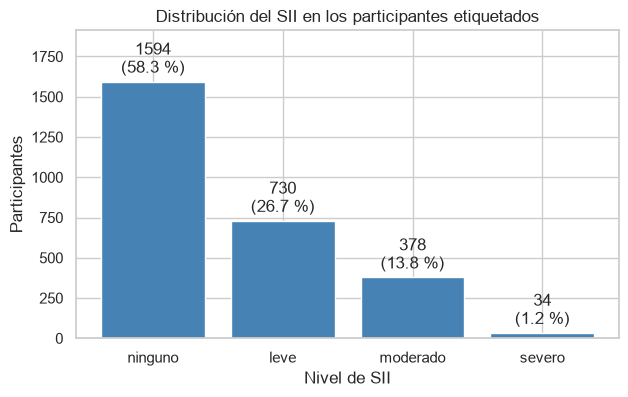

In [220]:
fig, ax = plt.subplots(figsize=(7, 4))
barras = ax.bar(distribucion_sii.index, distribucion_sii["participantes"], color="steelblue")
ax.bar_label(
    barras,
    labels=[
        f"{n}\n({p:.1f} %)"
        for n, p in zip(distribucion_sii["participantes"], distribucion_sii["%"])
    ],
    padding=3,
)
ax.set(
    xlabel="Nivel de SII",
    ylabel="Participantes",
    title="Distribución del SII en los participantes etiquetados",
)
ax.margins(y=0.2)
save_figure(fig, "sii_distribucion", FIGURES_DIR)
plt.show()

In [221]:
CORTES_PCIAT = [-1, 30, 49, 79, 100]

total_pciat = train["PCIAT-PCIAT_Total"]
nivel_por_corte = (
    pd.cut(total_pciat, bins=CORTES_PCIAT, labels=list(NIVELES_SII.values()))
    .cat.add_categories("sin puntaje total")
    .fillna("sin puntaje total")
)
sii_texto = train["sii"].map(NIVELES_SII).fillna("sin SII")

pd.crosstab(
    nivel_por_corte,
    sii_texto,
    rownames=["nivel según el puntaje total"],
    colnames=["SII registrado"],
).reindex(columns=[*NIVELES_SII.values(), "sin SII"], fill_value=0)

SII registrado,ninguno,leve,moderado,severo,sin SII
nivel según el puntaje total,,,,,
ninguno,1594,0,0,0,0
leve,0,730,0,0,0
moderado,0,0,378,0,0
severo,0,0,0,34,0
sin puntaje total,0,0,0,0,1224


In [222]:
items_pciat = [
    c for c in train.columns if c.startswith("PCIAT-PCIAT_") and c != "PCIAT-PCIAT_Total"
]

items_faltantes = train.loc[etiquetados, items_pciat].isna().sum(axis="columns")
display(
    items_faltantes.value_counts()
    .sort_index()
    .rename_axis("ítems faltantes")
    .rename("participantes etiquetados")
)

suma_items = train.loc[etiquetados, items_pciat].sum(axis="columns", min_count=1)
con_faltantes = items_faltantes > 0
total_maximo = (
    total_pciat[etiquetados][con_faltantes] + 5 * items_faltantes[con_faltantes]
).clip(upper=100)
nivel_maximo = pd.cut(total_maximo, bins=CORTES_PCIAT, labels=False)
sii_con_faltantes = train.loc[etiquetados, "sii"][con_faltantes]

pd.Series(
    {
        "puntaje total distinto de la suma de ítems": (
            suma_items != total_pciat[etiquetados]
        ).sum(),
        "etiquetados con ítems faltantes": con_faltantes.sum(),
        "con nivel máximo posible mayor al registrado": (
            nivel_maximo > sii_con_faltantes
        ).sum(),
    },
    name="conteo",
)

ítems faltantes
0     2671
1       52
2        9
3        1
5        1
10       1
20       1
Name: participantes etiquetados, dtype: int64

puntaje total distinto de la suma de ítems       1
etiquetados con ítems faltantes                 65
con nivel máximo posible mayor al registrado    17
Name: conteo, dtype: int64

In [223]:
discrepantes = suma_items.ne(total_pciat[etiquetados]) & items_faltantes.lt(len(items_pciat))
pd.Series(
    {
        "etiquetados sin ninguna respuesta a los ítems": (items_faltantes == len(items_pciat)).sum(),
        "discrepancias con al menos un ítem respondido": discrepantes.sum(),
    },
    name="conteo",
)

etiquetados sin ninguna respuesta a los ítems    1
discrepancias con al menos un ítem respondido    0
Name: conteo, dtype: int64

In [224]:
columnas_medicion = estructura[estructura["grupo"] != "temporada de instrumento"]


def cobertura_por_instrumento(datos: pd.DataFrame) -> pd.Series:
    """Porcentaje de participantes con al menos una medición de cada instrumento."""
    cobertura = {
        instrumento: 100 * datos[columnas.index].notna().any(axis="columns").mean()
        for instrumento, columnas in columnas_medicion.groupby("instrumento", sort=False)
    }
    cobertura["Parent-Child Internet Addiction Test"] = (
        100 * datos[[*items_pciat, "PCIAT-PCIAT_Total"]].notna().any(axis="columns").mean()
    )
    return pd.Series(cobertura).add_prefix("% con ")


comparacion = pd.DataFrame(
    {
        nombre: pd.concat(
            [
                pd.Series(
                    {
                        "participantes": len(datos),
                        "edad media": datos["Basic_Demos-Age"].mean(),
                        "edad mediana": datos["Basic_Demos-Age"].median(),
                        "% mujeres": 100 * datos["Basic_Demos-Sex"].mean(),
                    }
                ),
                cobertura_por_instrumento(datos),
            ]
        )
        for nombre, datos in {
            "con SII": train[etiquetados],
            "sin SII": train[~etiquetados],
        }.items()
    }
).round(1)
comparacion

,con SII,sin SII
participantes,2736.0,1224.0
edad media,10.2,10.9
edad mediana,10.0,10.0
% mujeres,36.4,39.1
% con Demographics,100.0,100.0
% con Children's Global Assessment Scale,85.6,6.5
% con Physical Measures,94.2,41.3
% con FitnessGram Vitals and Treadmill,26.7,1.0
% con FitnessGram Child,70.2,33.3
% con Bio-electric Impedance Analysis,66.3,14.5


In [225]:
SEXO = {0: "masculino", 1: "femenino"}
GRUPOS_EDAD = ["5–12", "13–17", "18–22"]

etiquetados_df = train[etiquetados]
grupo_edad = pd.cut(etiquetados_df["Basic_Demos-Age"], bins=[4, 12, 17, 22], labels=GRUPOS_EDAD)
sexo = etiquetados_df["Basic_Demos-Sex"].map(SEXO)
sii_etiquetados = etiquetados_df["sii"].astype(int).map(NIVELES_SII)
columnas_sii = [*NIVELES_SII.values(), "total"]

display(
    pd.crosstab(
        [sexo, grupo_edad],
        sii_etiquetados,
        rownames=["sexo", "grupo de edad"],
        colnames=["SII"],
        margins=True,
        margins_name="total",
    ).reindex(columns=columnas_sii)
)

display(
    (
        100
        * pd.crosstab(sexo, sii_etiquetados, normalize="index").reindex(
            columns=list(NIVELES_SII.values())
        )
    )
    .round(1)
    .rename_axis(index="sexo", columns="SII (%)")
)

proporciones_edad = (
    100
    * pd.crosstab(grupo_edad, sii_etiquetados, normalize="index").reindex(
        columns=list(NIVELES_SII.values())
    )
).rename_axis(index="grupo de edad", columns="SII (%)")
proporciones_edad.round(1)

SII                      ninguno  leve  moderado  severo  total
sexo      grupo de edad                                        
femenino  5–12               529   151        42       1    723
          13–17               96    86        54       5    241
          18–22               13    12         6       2     33
masculino 5–12               834   347       161       5   1347
          13–17              103   116       103      19    341
          18–22               19    18        12       2     51
total                       1594   730       378      34   2736

SII (%),ninguno,leve,moderado,severo
sexo,,,,
femenino,64.0,25.0,10.2,0.8
masculino,55.0,27.7,15.9,1.5


SII (%),ninguno,leve,moderado,severo
grupo de edad,,,,
5–12,65.8,24.1,9.8,0.3
13–17,34.2,34.7,27.0,4.1
18–22,38.1,35.7,21.4,4.8


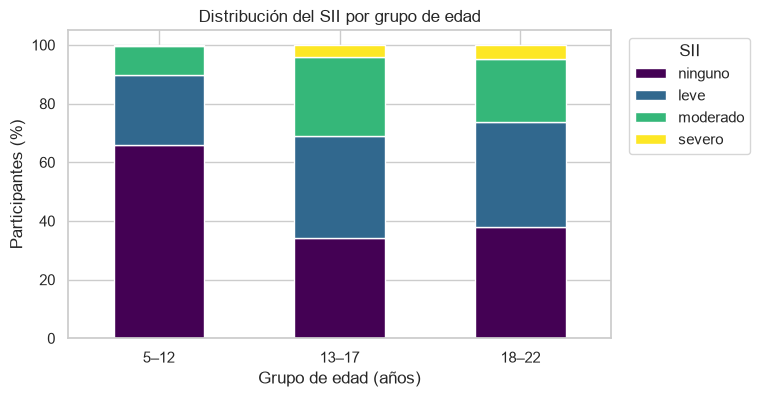

In [226]:
fig, ax = plt.subplots(figsize=(7, 4))
proporciones_edad.plot(kind="bar", stacked=True, ax=ax, colormap="viridis", rot=0)
ax.set(
    xlabel="Grupo de edad (años)",
    ylabel="Participantes (%)",
    title="Distribución del SII por grupo de edad",
)
ax.legend(title="SII", bbox_to_anchor=(1.02, 1), loc="upper left")
save_figure(fig, "sii_por_grupo_edad", FIGURES_DIR)
plt.show()

In [227]:
N_PARTICIONES = 5

conteo_clases = train.loc[etiquetados, "sii"].astype(int).value_counts().sort_index()
n_etiquetados = conteo_clases.sum()
n_clases = len(conteo_clases)

pesos_clase = pd.DataFrame(
    {
        "participantes": conteo_clases,
        "peso de clase": (n_etiquetados / (n_clases * conteo_clases)).round(2),
        "casos por partición externa de evaluación": (
            conteo_clases / N_PARTICIONES
        ).round(1),
        "casos por partición interna de evaluación": (
            conteo_clases * (N_PARTICIONES - 1) / N_PARTICIONES**2
        ).round(1),
    }
).rename(index=NIVELES_SII)
pesos_clase.index.name = "SII"
pesos_clase

,participantes,peso de clase,casos por partición externa de evaluación,casos por partición interna de evaluación
SII,,,,
ninguno,1594,0.43,318.8,255.0
leve,730,0.94,146.0,116.8
moderado,378,1.81,75.6,60.5
severo,34,20.12,6.8,5.4


### Conclusión

#### Población de análisis

| | Participantes | % |
|---|---|---|
| Con SII | 2.736 | 69,1 |
| Sin SII | 1.224 | 30,9 |
| Total | 3.960 | 100,0 |

Ninguno de los participantes sin SII tiene respuestas del PCIAT, por lo que su nivel de severidad no puede reconstruirse. Frente a los etiquetados, presentan un perfil demográfico similar, pero una cobertura menor en los instrumentos de evaluación:

| | Con SII | Sin SII |
|---|---|---|
| Edad media (años) | 10,2 | 10,9 |
| Mujeres (%) | 36,4 | 39,1 |
| Con medidas físicas (%) | 94,2 | 41,3 |
| Con escala de sueño (%) | 92,4 | 6,7 |
| Con funcionamiento global (%) | 85,6 | 6,5 |

La ausencia del SII se concentra en participantes que completaron una parte menor de la evaluación, más que en un perfil demográfico distinto. El análisis se restringe a los 2.736 participantes etiquetados, con la salvedad de que representan a quienes completaron una proporción mayor del protocolo del Healthy Brain Network.

#### Calidad de la variable objetivo

- **Consistencia con el PCIAT:** en todos los participantes etiquetados, el SII coincide con el nivel que corresponde al puntaje total según los puntos de corte; es una discretización directa de ese puntaje.
- **Ítems sin responder:** 65 participantes etiquetados (2,4 %) tienen al menos un ítem faltante, y en 52 de ellos falta uno solo. En todos los participantes con al menos un ítem respondido, el puntaje total coincide con la suma de los ítems respondidos, de modo que los ítems faltantes se contabilizan como cero. Un participante tiene registrado el puntaje total sin ninguna respuesta a los ítems, por lo que su puntaje no puede verificarse.
- **Posible subestimación:** en 17 participantes, el nivel podría ser mayor al registrado si los ítems faltantes hubieran recibido la puntuación máxima. Estos casos se conservan con el SII registrado, porque reconstruir las respuestas faltantes requeriría supuestos sin respaldo en los datos; constituyen una fuente de ruido en la variable objetivo que tiende a subestimar la severidad.

#### Distribución por sexo y edad

| Subgrupo | Participantes | Moderado o severo (%) | Casos severos |
|---|---|---|---|
| Mujeres | 997 | 11,0 | 8 |
| Hombres | 1.739 | 17,4 | 26 |
| 5 a 12 años | 2.070 | 10,1 | 6 |
| 13 a 17 años | 582 | 31,1 | 24 |
| 18 a 22 años | 84 | 26,2 | 4 |

- La proporción de PIU moderado o severo es mayor en hombres que en mujeres y aumenta de forma marcada de la infancia a la adolescencia. El grupo de 18 a 22 años muestra una proporción menor que el de 13 a 17, pero con 84 participantes la diferencia no permite afirmar una tendencia en ese tramo.
- La edad y el sexo se asocian de forma descriptiva con el SII, por lo que se espera que el modelo de referencia supere el desempeño por azar. Esto refuerza el diseño de la comparación: el conjunto principal debe aportar información más allá de la que ya contienen la edad y el sexo.
- Al cruzar sexo y grupo de edad, las celdas del nivel severo tienen entre 1 y 19 casos. Por ello, el análisis de errores por subgrupo compara sexos y grupos de edad por separado, y usa la tasa de subestimación de los niveles moderado y severo en conjunto.

#### Desbalance y validación

| SII | Participantes | Peso de clase | Casos por partición externa | Casos por partición interna |
|---|---|---|---|---|
| Ninguno | 1.594 | 0,43 | 318,8 | 255,0 |
| Leve | 730 | 0,94 | 146,0 | 116,8 |
| Moderado | 378 | 1,81 | 75,6 | 60,5 |
| Severo | 34 | 20,12 | 6,8 | 5,4 |

Con cinco particiones estratificadas, las estimaciones de sensibilidad del nivel severo y los umbrales que se optimizan en la validación interna se apoyan en muy pocos casos. Esto justifica repetir la validación cruzada con varias semillas y reportar la variabilidad entre repeticiones.

## 4. Cobertura y patrón de valores faltantes

Cada instrumento se aplica o no a cada participante, por lo que se espera que la ausencia de datos se presente por bloques y no de forma independiente en cada variable. Esta sección verifica esa estructura en los 2.736 participantes etiquetados, que constituyen la población de análisis. Se examinan:

- la cobertura de cada instrumento y la completitud de sus variables entre quienes lo tienen;
- las combinaciones de instrumentos más frecuentes y la co-ocurrencia entre instrumentos;
- la relación de la cobertura con la edad, incluida la aplicación de las dos versiones del cuestionario de actividad física, para adolescentes (PAQ-A) y para niños (PAQ-C);
- la correspondencia entre las columnas de temporada y la presencia de cada instrumento;
- la cobertura por nivel de SII, de forma descriptiva.

Con estos resultados se definen las estrategias candidatas de tratamiento de los faltantes, el uso de indicadores de ausencia, la integración de PAQ-A y PAQ-C, el destino de la resistencia cardiorrespiratoria y la inclusión de las temporadas de instrumento.

In [228]:
NOMBRES_INSTRUMENTO = {
    "Demographics": "Demográficas",
    "Physical Measures": "Medidas físicas",
    "FitnessGram Child": "FitnessGram",
    "FitnessGram Vitals and Treadmill": "Resistencia",
    "Bio-electric Impedance Analysis": "Bioimpedancia",
    "Physical Activity Questionnaire (Adolescents)": "PAQ-A",
    "Physical Activity Questionnaire (Children)": "PAQ-C",
    "Sleep Disturbance Scale": "SDS",
    "Children's Global Assessment Scale": "CGAS",
    "Internet Use": "Horas de internet",
}

medicion = estructura[estructura["grupo"] != "temporada de instrumento"].assign(
    instrumento_corto=lambda d: d["instrumento"].map(NOMBRES_INSTRUMENTO)
)
columnas_por_instrumento = {
    instrumento: list(columnas.index)
    for instrumento, columnas in medicion.groupby("instrumento_corto", sort=False)
}

presencia = pd.DataFrame(
    {
        instrumento: etiquetados_df[columnas].notna().any(axis="columns")
        for instrumento, columnas in columnas_por_instrumento.items()
    }
)
presencia["PAQ-A o PAQ-C"] = presencia["PAQ-A"] | presencia["PAQ-C"]

completitud = pd.DataFrame(
    {
        "columnas": pd.Series(
            {i: len(c) for i, c in columnas_por_instrumento.items()}, dtype="Int64"
        ),
        "% con el instrumento": 100 * presencia.mean(),
        "% completo entre quienes lo tienen": pd.Series(
            {
                i: 100
                * etiquetados_df.loc[presencia[i], c].notna().all(axis="columns").mean()
                for i, c in columnas_por_instrumento.items()
            }
        ),
    }
).round(1)
completitud.index.name = "instrumento"
completitud

,columnas,% con el instrumento,% completo entre quienes lo tienen
instrumento,,,
Bioimpedancia,16,66.3,100.0
CGAS,1,85.6,100.0
Demográficas,3,100.0,100.0
FitnessGram,14,70.2,43.8
Horas de internet,1,97.0,100.0
Medidas físicas,7,94.2,18.0
PAQ-A,1,13.3,100.0
PAQ-A o PAQ-C,<NA>,65.9,NaN
PAQ-C,1,52.6,100.0


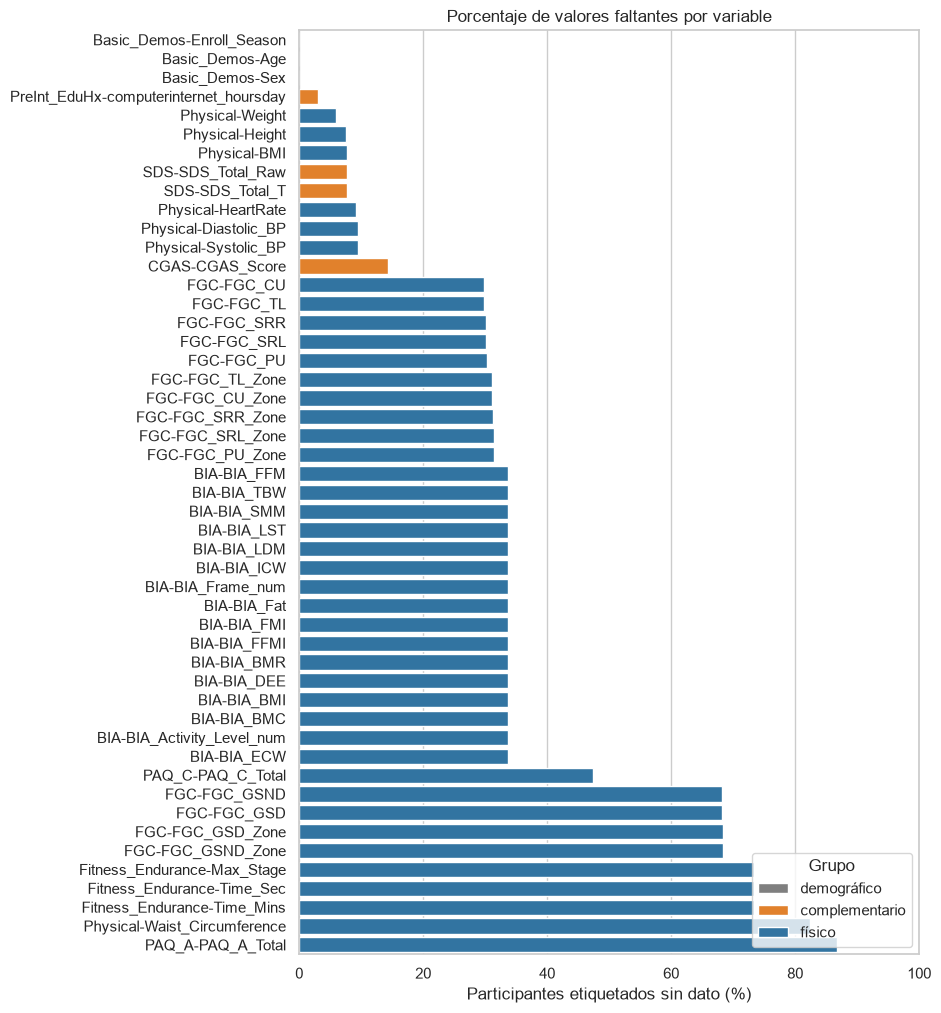

In [229]:
faltantes_variable = (
    (100 * etiquetados_df[medicion.index].isna().mean())
    .rename("% faltante")
    .rename_axis("columna")
    .to_frame()
    .join(medicion[["grupo", "instrumento_corto"]])
    .sort_values("% faltante")
)

fig, ax = plt.subplots(figsize=(8, 12))
sns.barplot(
    data=faltantes_variable.reset_index(),
    x="% faltante",
    y="columna",
    hue="grupo",
    dodge=False,
    palette={"demográfico": "tab:gray", "físico": "tab:blue", "complementario": "tab:orange"},
    ax=ax,
)
ax.set(
    xlabel="Participantes etiquetados sin dato (%)",
    ylabel="",
    title="Porcentaje de valores faltantes por variable",
    xlim=(0, 100),
)
ax.legend(title="Grupo", loc="lower right")
save_figure(fig, "faltantes_por_variable", FIGURES_DIR)
plt.show()

In [230]:
instrumentos_patron = [
    "Medidas físicas",
    "FitnessGram",
    "Resistencia",
    "Bioimpedancia",
    "PAQ-A o PAQ-C",
    "SDS",
    "CGAS",
    "Horas de internet",
]

conteo_patrones = presencia[instrumentos_patron].value_counts()
tabla_patrones = conteo_patrones.head(10).reset_index(name="participantes")
tabla_patrones[instrumentos_patron] = tabla_patrones[instrumentos_patron].map(
    lambda presente: "✓" if presente else ""
)
tabla_patrones["%"] = (100 * tabla_patrones["participantes"] / len(presencia)).round(1)

print(f"Combinaciones distintas de instrumentos: {len(conteo_patrones)}")
print(
    "Participantes cubiertos por las 10 combinaciones más frecuentes: "
    f"{100 * conteo_patrones.head(10).sum() / len(presencia):.1f} %"
)
display(tabla_patrones)

(
    presencia[instrumentos_patron]
    .sum(axis="columns")
    .value_counts()
    .sort_index()
    .rename_axis("instrumentos disponibles (de 8)")
    .rename("participantes")
)

Combinaciones distintas de instrumentos: 79
Participantes cubiertos por las 10 combinaciones más frecuentes: 71.8 %


,Medidas físicas,FitnessGram,Resistencia,Bioimpedancia,PAQ-A o PAQ-C,SDS,CGAS,Horas de internet,participantes,%
0,✓,✓,,✓,✓,✓,✓,✓,488,17.8
1,✓,✓,✓,✓,✓,✓,✓,✓,345,12.6
2,✓,,,,✓,✓,✓,✓,218,8.0
3,✓,✓,✓,✓,,✓,✓,✓,198,7.2
4,✓,✓,,✓,,✓,✓,✓,157,5.7
5,✓,,,✓,✓,✓,✓,✓,140,5.1
6,✓,✓,,✓,✓,✓,,✓,123,4.5
7,✓,,,,,✓,✓,✓,115,4.2
8,✓,✓,,,✓,✓,✓,✓,95,3.5
9,✓,✓,✓,,✓,✓,✓,✓,85,3.1


instrumentos disponibles (de 8)
0      2
1      7
2     23
3     84
4    312
5    516
6    655
7    792
8    345
Name: participantes, dtype: int64

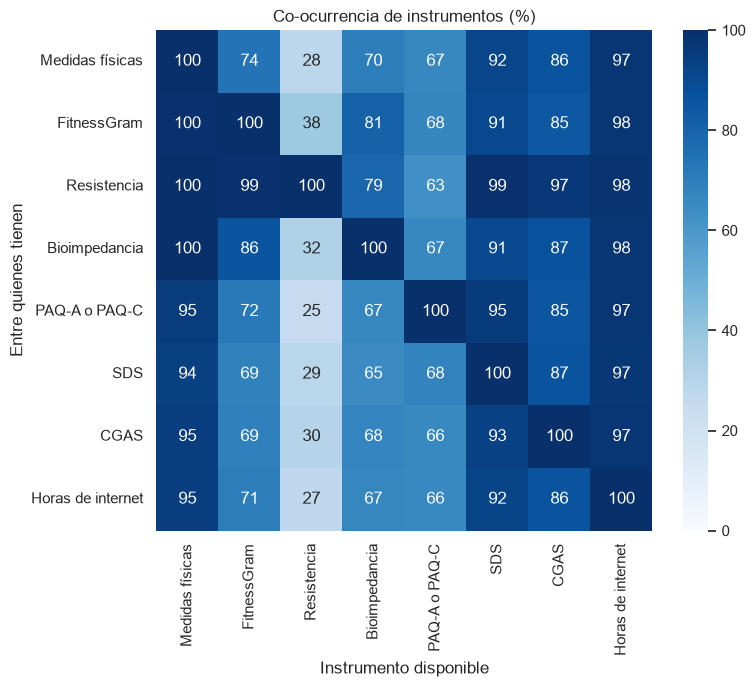

In [231]:
presencia_entera = presencia[instrumentos_patron].astype(int)
coocurrencia = (100 * (presencia_entera.T @ presencia_entera)).div(
    presencia_entera.sum(), axis="index"
)

fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(coocurrencia, annot=True, fmt=".0f", cmap="Blues", vmin=0, vmax=100, ax=ax)
ax.set(
    xlabel="Instrumento disponible",
    ylabel="Entre quienes tienen",
    title="Co-ocurrencia de instrumentos (%)",
)
save_figure(fig, "coocurrencia_instrumentos", FIGURES_DIR)
plt.show()

,Medidas físicas,FitnessGram,Resistencia,Bioimpedancia,PAQ-A o PAQ-C,SDS,CGAS,Horas de internet,PAQ-A,PAQ-C,participantes
grupo de edad,,,,,,,,,,,
5–12,94.3,70.7,35.3,66.1,58.8,95.2,86.5,97.6,0.0,58.8,2070
13–17,94.7,75.3,0.0,67.4,96.0,87.3,83.0,95.7,57.9,38.3,582
18–22,90.5,22.6,0.0,63.1,31.0,58.3,82.1,90.5,31.0,0.0,84


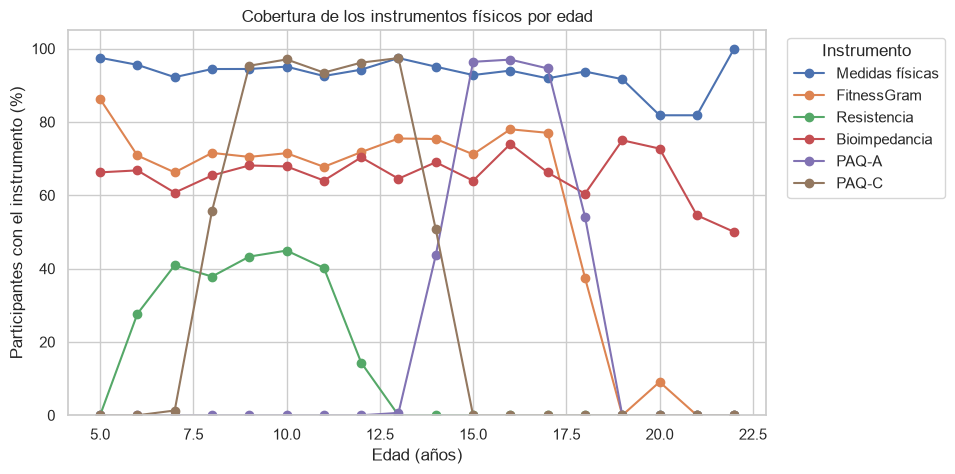

edad,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22
participantes,80,271,308,341,342,305,214,209,155,142,111,100,74,48,12,11,11,2


In [232]:
instrumentos_edad = [*instrumentos_patron, "PAQ-A", "PAQ-C"]

display(
    (100 * presencia[instrumentos_edad].groupby(grupo_edad, observed=True).mean())
    .round(1)
    .assign(participantes=grupo_edad.value_counts())
    .rename_axis("grupo de edad")
)

cobertura_edad = 100 * presencia[instrumentos_edad].groupby(
    etiquetados_df["Basic_Demos-Age"]
).mean()

fig, ax = plt.subplots(figsize=(9, 5))
cobertura_edad[
    ["Medidas físicas", "FitnessGram", "Resistencia", "Bioimpedancia", "PAQ-A", "PAQ-C"]
].plot(marker="o", ax=ax)
ax.set(
    xlabel="Edad (años)",
    ylabel="Participantes con el instrumento (%)",
    title="Cobertura de los instrumentos físicos por edad",
    ylim=(0, 105),
)
ax.legend(title="Instrumento", bbox_to_anchor=(1.02, 1), loc="upper left")
save_figure(fig, "cobertura_por_edad", FIGURES_DIR)
plt.show()

etiquetados_df["Basic_Demos-Age"].value_counts().sort_index().rename_axis("edad").rename(
    "participantes"
).to_frame().T

In [233]:
display(
    pd.crosstab(
        presencia["PAQ-A"],
        presencia["PAQ-C"],
        rownames=["con PAQ-A"],
        colnames=["con PAQ-C"],
        margins=True,
        margins_name="total",
    )
)

version_paq = pd.Series(
    np.select(
        [
            presencia["PAQ-A"] & presencia["PAQ-C"],
            presencia["PAQ-A"],
            presencia["PAQ-C"],
        ],
        ["ambos", "solo PAQ-A", "solo PAQ-C"],
        default="ninguno",
    ),
    index=presencia.index,
    name="versión del PAQ",
)
display(
    etiquetados_df.groupby(version_paq)["Basic_Demos-Age"]
    .agg(["count", "min", "median", "max"])
    .rename(columns={"count": "participantes"})
)

etiquetados_df[["PAQ_A-PAQ_A_Total", "PAQ_C-PAQ_C_Total"]].describe().round(2)

con PAQ-C,False,True,total
con PAQ-A,,,
False,934,1439,2373
True,362,1,363
total,1296,1440,2736


,participantes,min,median,max
versión del PAQ,,,,
ambos,1,13,13.0,13
ninguno,934,5,7.0,22
solo PAQ-A,362,14,16.0,18
solo PAQ-C,1439,7,10.0,14


,PAQ_A-PAQ_A_Total,PAQ_C-PAQ_C_Total
count,363.00,1440.00
mean,2.19,2.59
std,0.82,0.79
min,0.66,0.58
25%,1.52,2.02
50%,2.08,2.55
75%,2.78,3.16
max,4.54,4.79


In [234]:
temporadas_instrumento = estructura[estructura["grupo"] == "temporada de instrumento"]

filas = []
for columna_temporada, instrumento in temporadas_instrumento["instrumento"].items():
    tiene_temporada = etiquetados_df[columna_temporada].notna()
    tiene_medicion = presencia[NOMBRES_INSTRUMENTO[instrumento]]
    filas.append(
        {
            "instrumento": NOMBRES_INSTRUMENTO[instrumento],
            "temporada y medición": (tiene_temporada & tiene_medicion).sum(),
            "solo temporada": (tiene_temporada & ~tiene_medicion).sum(),
            "solo medición": (~tiene_temporada & tiene_medicion).sum(),
            "ninguna": (~tiene_temporada & ~tiene_medicion).sum(),
        }
    )

pd.DataFrame(filas).set_index("instrumento")

,temporada y medición,solo temporada,solo medición,ninguna
instrumento,,,,
CGAS,2342,0,0,394
Medidas físicas,2578,17,0,141
Resistencia,731,529,0,1476
FitnessGram,1920,727,0,89
Bioimpedancia,1813,31,0,892
PAQ-A,363,0,0,2373
PAQ-C,1440,0,0,1296
SDS,2527,0,0,209
Horas de internet,2654,65,0,17


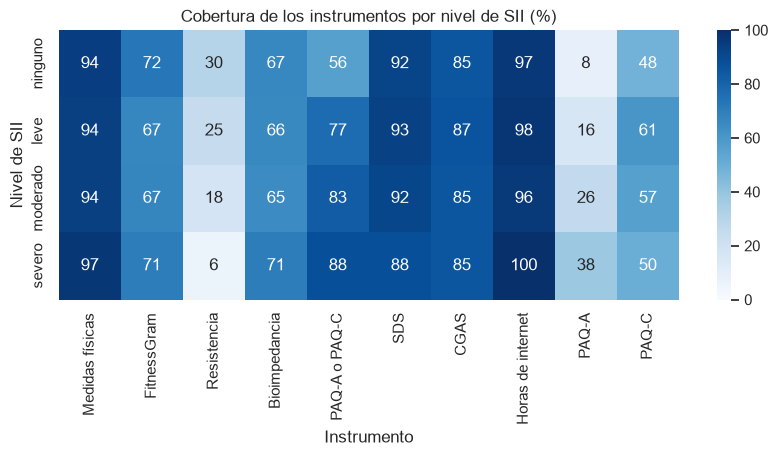

,Medidas físicas,FitnessGram,Resistencia,Bioimpedancia,PAQ-A o PAQ-C,SDS,CGAS,Horas de internet,PAQ-A,PAQ-C,participantes
SII,,,,,,,,,,,
ninguno,94.3,72.4,30.2,66.8,56.3,92.3,85.3,96.7,8.2,48.1,1594
leve,94.1,66.8,24.7,65.8,76.7,93.2,86.6,97.9,16.3,60.5,730
moderado,93.9,67.2,17.7,64.8,83.1,91.5,85.2,96.0,26.5,56.6,378
severo,97.1,70.6,5.9,70.6,88.2,88.2,85.3,100.0,38.2,50.0,34


In [235]:
cobertura_sii = (
    100 * presencia[instrumentos_edad].groupby(sii_etiquetados).mean()
).reindex(list(NIVELES_SII.values()))
cobertura_sii.index.name = "SII"

fig, ax = plt.subplots(figsize=(10, 3.5))
sns.heatmap(cobertura_sii, annot=True, fmt=".0f", cmap="Blues", vmin=0, vmax=100, ax=ax)
ax.set(
    xlabel="Instrumento",
    ylabel="Nivel de SII",
    title="Cobertura de los instrumentos por nivel de SII (%)",
)
save_figure(fig, "cobertura_por_sii", FIGURES_DIR)
plt.show()

cobertura_sii.round(1).assign(participantes=sii_etiquetados.value_counts())